Loading images from local paths...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 107MB/s] 


Running Neural Style Transfer... (This will take a few minutes)
Epoch [50/300] Total Loss: 86142992.0000
Epoch [100/300] Total Loss: 18964118.0000
Epoch [150/300] Total Loss: 5476307.0000
Epoch [200/300] Total Loss: 3819430.7500
Epoch [250/300] Total Loss: 3055367.7500
Epoch [300/300] Total Loss: 2559057.7500


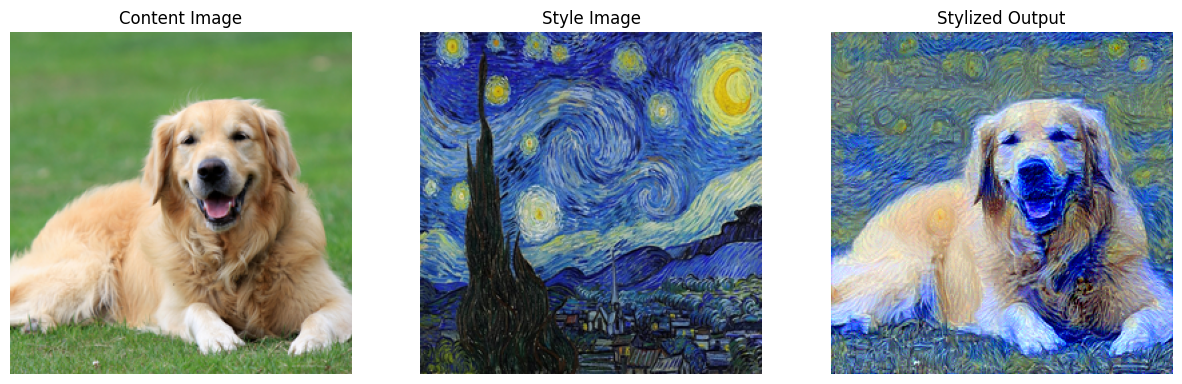

In [6]:

!pip install torch torchvision pillow matplotlib tqdm --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os


CONTENT_PATH = "CONTENT_PATH.png"
STYLE_PATH = "STYLE_PATH.jpg"

if not os.path.exists(CONTENT_PATH):
    raise FileNotFoundError(f"Content image not found at {CONTENT_PATH}. Make sure it is uploaded to the Colab files pane.")
if not os.path.exists(STYLE_PATH):
    raise FileNotFoundError(f"Style image not found at {STYLE_PATH}. Make sure it is uploaded to the Colab files pane.")

def load_image(img_path, size=(256, 256)):
    """Loads an image from a file path and applies transformations"""
    image = Image.open(img_path).convert('RGB')
    image = image.resize(size, Image.Resampling.LANCZOS)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])
    return transform(image).unsqueeze(0)

def im_convert(tensor):
    """Helper function to un-normalize and display images"""
    image = tensor.cpu().clone().detach().squeeze(0).numpy().transpose(1, 2, 0)
    image = image * np.array((0.229, 0.224, 0.225)) + np.array((0.485, 0.456, 0.406))
    return image.clip(0, 1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading images from local paths...")
content_image = load_image(CONTENT_PATH).to(device)
style_image = load_image(STYLE_PATH).to(device)

vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()
for param in vgg.parameters():
    param.requires_grad_(False)

def get_features(image, model):
    layers = {
        '0': 'conv1_1', '5': 'conv2_1', '10': 'conv3_1', # Style layers
        '19': 'conv4_1', '21': 'conv4_2', '28': 'conv5_1' # conv4_2 is the Content layer
    }
    features = {}
    x = image
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
    return features

def gram_matrix(tensor):
    """Calculates the Gram Matrix for style feature representation"""
    _, d, h, w = tensor.size()
    tensor = tensor.view(d, h * w)
    return torch.mm(tensor, tensor.t())

content_features = get_features(content_image, vgg)
style_features = get_features(style_image, vgg)
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

target_image = content_image.clone().requires_grad_(True).to(device)

style_weights = {'conv1_1': 1., 'conv2_1': 0.8, 'conv3_1': 0.5, 'conv4_1': 0.3, 'conv5_1': 0.1}
content_weight = 1
style_weight = 1e6


optimizer = optim.Adam([target_image], lr=0.03)

print("Running Neural Style Transfer... (This will take a few minutes)")
epochs = 300
for epoch in range(1, epochs + 1):
    target_features = get_features(target_image, vgg)


    content_loss = torch.mean((target_features['conv4_2'] - content_features['conv4_2'])**2)


    style_loss = 0
    for layer in style_weights:
        target_feature = target_features[layer]
        target_gram = gram_matrix(target_feature)
        _, d, h, w = target_feature.shape
        style_gram = style_grams[layer]
        layer_style_loss = style_weights[layer] * torch.mean((target_gram - style_gram)**2)
        style_loss += layer_style_loss / (d * h * w)


    total_loss = content_weight * content_loss + style_weight * style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch [{epoch}/{epochs}] Total Loss: {total_loss.item():.4f}")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.imshow(im_convert(content_image))
ax1.set_title("Content Image")
ax2.imshow(im_convert(style_image))
ax2.set_title("Style Image")
ax3.imshow(im_convert(target_image))
ax3.set_title("Stylized Output")
for ax in [ax1, ax2, ax3]: ax.axis('off')
plt.show()